# Credit Risk Project 

Understanding our Dataset

* checking_status: The currently balance account.
* duration: duration of the credit payment, in months.
* credit_history: Is the customer credit history. It can have the following values:
* existing paid: currently credit process
* all paid: all the credit abre paid by the customer
* delayed previously: past delays at # the credit payment
* critical/ other existing credit: critical credit accounts
* no credits/ all paid: customer that never gets credit.
* purpose: porpouse of the credit requested.
* credit_amount: Amount of the credit requested
* savings_status: Balance account of savings/ bond.
* employment:How many years the customer has employed.
* installment_commitment: Percentual that the customer cannot reach due to the income.

--> When a customer takes a credit, the installment cannot ultrapass a percentual of customer income.
* personal_status: if is divorced, married, etc.
* other_parties: Another part involde on th credit, like guarantos ("fiador").
* residence_since: How many year the customer has in the country.
* property_magnitude: The good of the customer.
* age: The age of the customer.
* other_payment_plans: If the customer has another credit line and how the type (store, bank, etc).
* housing:The housing customer type, could be own, for free or rent.
* existing_credits: Number of existing credits at this bank.
* job: This represents whats type of job the customer has. Could be skilled, unskilled resident, high qualif/self emp/mgmt and unemp/unskilled non res.
* num_dependents: The number of depedents that live wth the customer.
* own_telephone: If the customer has a telephone.
* foreign_worker: If the customer is a foreign or not.
* class: Our target. If the credit is goos or bad to the bank.

### Importing Libraries to start EDA (Exploratory Data Analysis)

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

### Importing Dataset

In [2]:
# Importing the dataset
raw_data = pd.read_csv("credit_customers.csv",delimiter=',')
df = raw_data.copy()
df.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6.0,critical/other existing credit,radio/tv,1169.0,no known savings,>=7,4.0,male single,none,...,real estate,67.0,none,own,2.0,skilled,1.0,yes,yes,good
1,0<=X<200,48.0,existing paid,radio/tv,5951.0,<100,1<=X<4,2.0,female div/dep/mar,none,...,real estate,22.0,none,own,1.0,skilled,1.0,none,yes,bad
2,no checking,12.0,critical/other existing credit,education,2096.0,<100,4<=X<7,2.0,male single,none,...,real estate,49.0,none,own,1.0,unskilled resident,2.0,none,yes,good
3,<0,42.0,existing paid,furniture/equipment,7882.0,<100,4<=X<7,2.0,male single,guarantor,...,life insurance,45.0,none,for free,1.0,skilled,2.0,none,yes,good
4,<0,24.0,delayed previously,new car,4870.0,<100,1<=X<4,3.0,male single,none,...,no known property,53.0,none,for free,2.0,skilled,2.0,none,yes,bad


### Face 1: Executing Data cleaning

In [3]:
df.dtypes # All the values seems to be in the correct format
df.isnull().sum() # Checking for null values --> We do not have any null values in the dataset
df = df.drop_duplicates() # Dropping duplicates

    
    
# Cleaning the values from the job column for better understanding
df['job'] = df['job'].str.replace('unskilled resident','unskilled')
df['job'] = df['job'].str.replace('high qualif/self emp/mgmt','highqualif / selfemp')
df['job'] = df['job'].str.replace('unemp/unskilled non res','unemp/unsk/ nonres')

-----

### Face 2: Data Visualization

For this part of the project I decided to set questions / tasks  and answer them using plots.

#### 

       duration
count   1000.00
mean      20.90
std       12.06
min        4.00
25%       12.00
50%       18.00
75%       24.00
max       72.00 



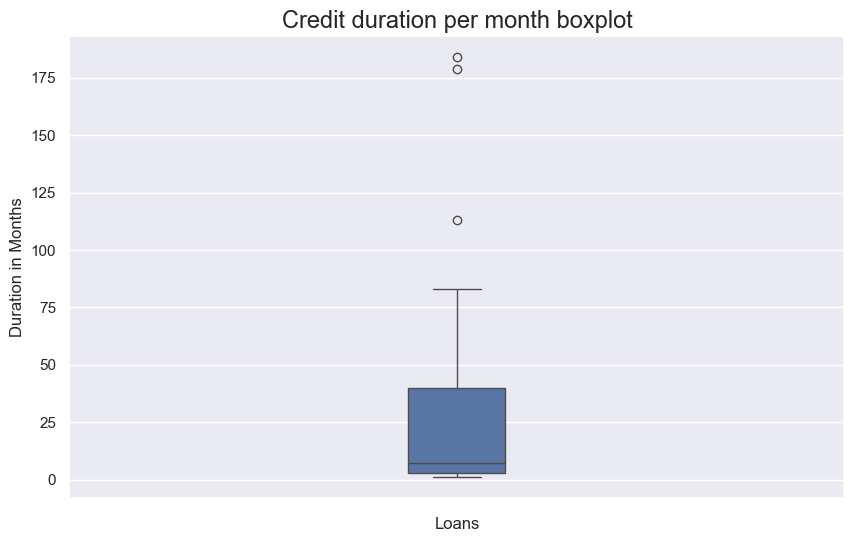



The mean loan duration is 20.9
The std loan duration is 12.06
The min loan duration is 4.0
The 25% loan duration is 12.0
The 50% loan duration is 18.0
The 75% loan duration is 24.0
The max loan duration is 72.0


In [4]:
# Getting the measures of central tendencies by duration
df_duration= df[['duration']].describe().round(2)
print(df_duration,'\n')

# Duration boxplot
df1 = df.groupby('duration')[['duration']].count()

plt.figure(figsize=(10,6))
sns.boxplot(data=df1,y=df1["duration"],width=0.125)
plt.ylabel('Duration in Months')
plt.xlabel('Loans')
plt.title('Credit duration per month boxplot', fontdict={'fontsize':'17'}, loc='center')
plt.show()

# Printing results
print('\n')
for i in range(1,len(df_duration['duration'])):
    print(f'The {df_duration.index[i]} loan duration is {df_duration.iloc[i,0]}')

#### Task / Question 2: Check the loan frequencies per purpose and their weight agaist to the total amount of loans

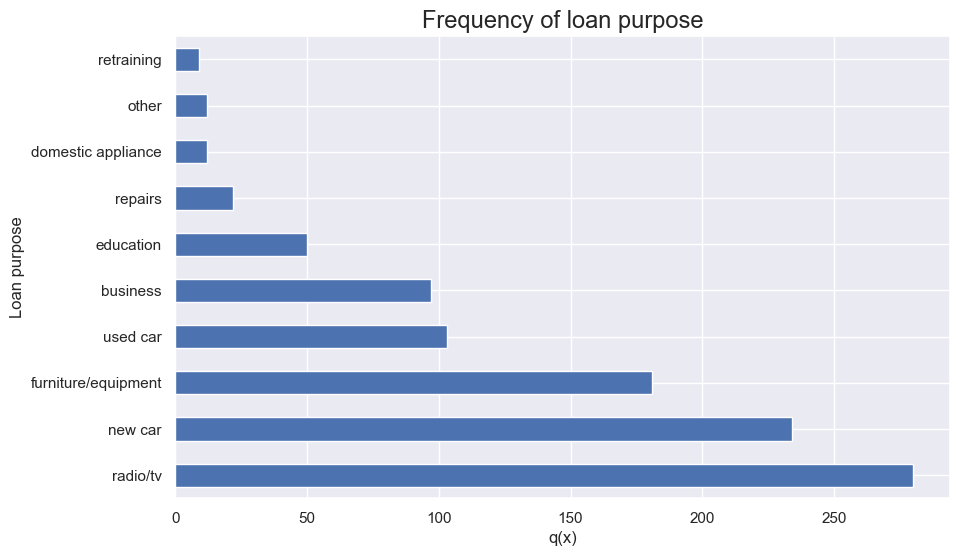

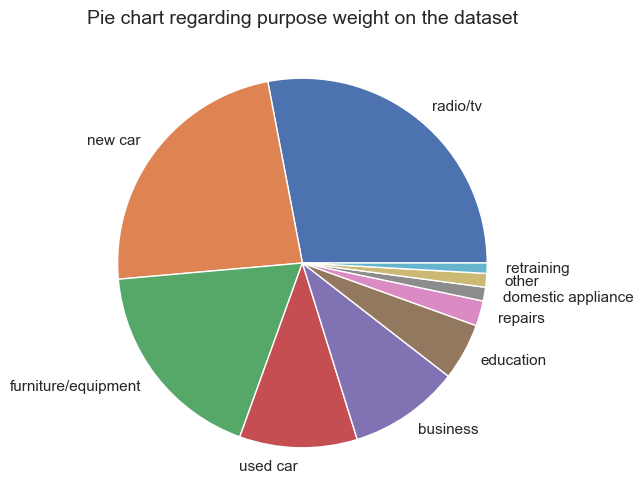


                      q(x)  Total  Weight
purpose                                 
radio/tv              280   1000    28.0
new car               234   1000    23.4
furniture/equipment   181   1000    18.1
used car              103   1000    10.3
business               97   1000     9.7
education              50   1000     5.0
repairs                22   1000     2.2
domestic appliance     12   1000     1.2
other                  12   1000     1.2
retraining              9   1000     0.9 

The purpose radio/tv represent the 28.0% from the total amount of loans
The purpose new car represent the 23.4% from the total amount of loans
The purpose furniture/equipment represent the 18.1% from the total amount of loans
The purpose used car represent the 10.3% from the total amount of loans
The purpose business represent the 9.7% from the total amount of loans
The purpose education represent the 5.0% from the total amount of loans
The purpose repairs represent the 2.2% from the total amount of

In [5]:
# Loan purpose frequency
df2 = df.groupby('purpose')[['credit_amount']].count().sort_values(by='credit_amount',ascending=False)

df2.plot(kind='barh',legend=False,figsize=(10,6))
plt.title('Frequency of loan purpose',fontdict={'fontsize':'17'}, loc='center')
plt.ylabel('Loan purpose')
plt.xlabel('q(x)')
plt.show()

# % Weight per purpose
df2 = df['purpose'].value_counts().to_frame()
df2['Total'] = 1000
df2.rename(columns={'count':'q(x)'},inplace= True)
df2['Weight'] = round((df2['q(x)']/df2['Total'])*100,2)


# Plot with labels and percentage
df2.plot(kind='pie',y='Weight', legend=None, figsize = (12,6))
plt.title('Pie chart regarding purpose weight on the dataset',fontdict={'fontsize':'14'},loc='center')
plt.show()

print('\n',df2,'\n')
for i in range(len(df2['Weight'])):
    print(f'The purpose {df2.index[i]} represent the {df2.iloc[i,2]}% from the total amount of loans')

-----

#### Task / Question 3: Check the measures of central tendencies regarding Credit Amount by Purpose

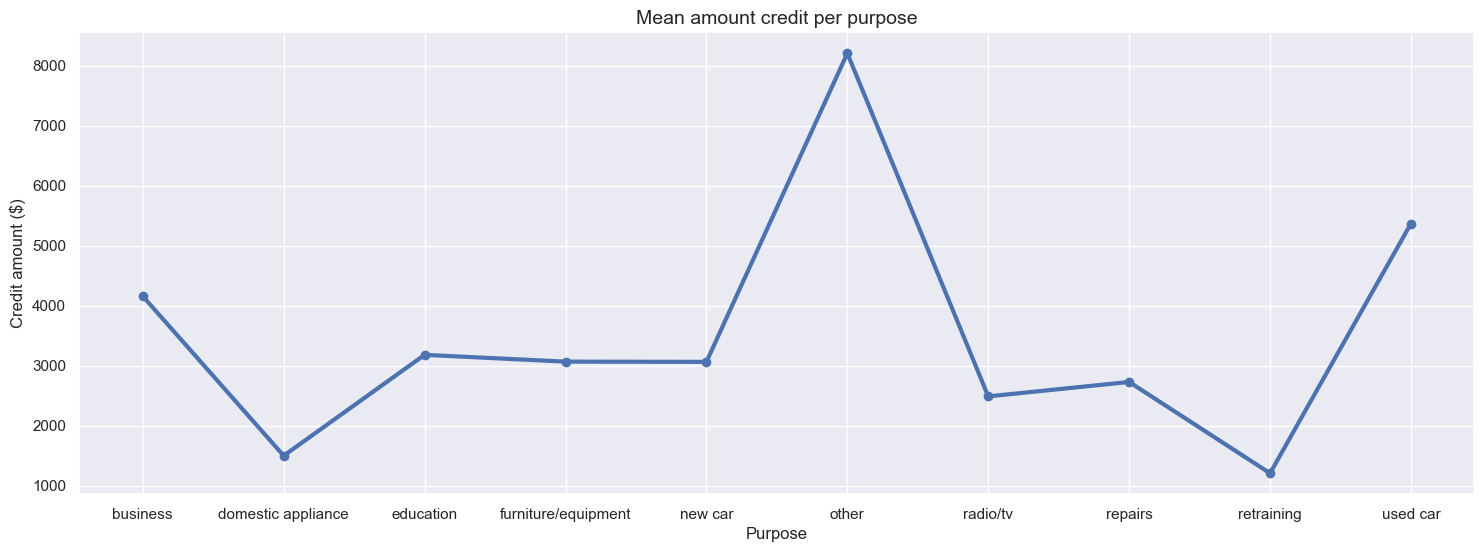



The mean credit amount taken for the purpose business is 4158.04 american dollars.
The min credit amount taken for the purpose business is 609.0 american dollars.
The max credit amount taken for the purpose business is 15945.0 american dollars.


The mean credit amount taken for the purpose domestic appliance is 1498.0 american dollars.
The min credit amount taken for the purpose domestic appliance is 343.0 american dollars.
The max credit amount taken for the purpose domestic appliance is 3990.0 american dollars.


The mean credit amount taken for the purpose education is 3180.4 american dollars.
The min credit amount taken for the purpose education is 392.0 american dollars.
The max credit amount taken for the purpose education is 12612.0 american dollars.


The mean credit amount taken for the purpose furniture/equipment is 3066.99 american dollars.
The min credit amount taken for the purpose furniture/equipment is 428.0 american dollars.
The max credit amount taken for the purpos

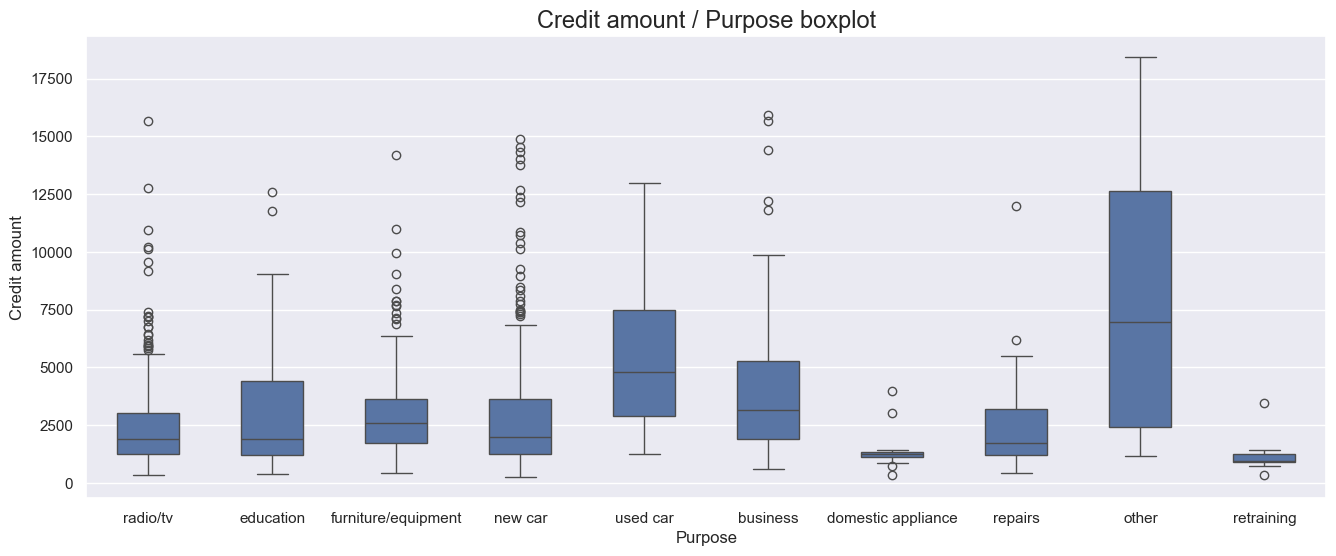

,purpose,count,mean,std,min,25%,50%,75%,max
0,business,97.0,4158.04,3231.48,609.0,1908.00,3161.0,5293.00,15945.0
1,domestic appliance,12.0,1498.00,1012.51,343.0,1131.25,1249.0,1359.50,3990.0
2,education,50.0,3180.40,3017.94,392.0,1198.25,1884.5,4425.25,12612.0
3,furniture/equipment,181.0,3066.99,2034.15,428.0,1747.00,2578.0,3643.00,14179.0
4,new car,234.0,3063.03,2962.65,250.0,1241.50,1980.0,3632.50,14896.0
5,other,12.0,8209.33,6112.70,1164.0,2410.50,6948.0,12649.00,18424.0
6,radio/tv,280.0,2487.65,2073.69,338.0,1261.00,1890.0,3038.00,15653.0
7,repairs,22.0,2728.09,2627.49,454.0,1214.50,1749.0,3203.25,11998.0
8,retraining,9.0,1205.89,891.48,339.0,894.00,932.0,1238.00,3447.0
9,used car,103.0,5370.22,2890.97,1236.0,2917.00,4788.0,7498.00,12976.0


In [6]:
# Groupping by purpose and describing credit amount column
df3 = df.groupby('purpose')['credit_amount'].describe().T.round(2)
df3

# Line chart of mean credit amount requested per purpose
df3 = df3.T.reset_index()
purpose = df3['purpose']
mean_AC = df3['mean']

plt.figure(figsize=(18,6))
plt.plot(purpose,mean_AC,linewidth=3, marker='o')
plt.xlabel('Purpose')
plt.ylabel('Credit amount ($)')
plt.title('Mean amount credit per purpose',fontdict={'fontsize':'14'},loc='center')
plt.show()

df3

# Mean, min & max credit amount taken per purpose 
print('\n')
for i in range(0,len(df3.columns)):
    print(f'The mean credit amount taken for the purpose {df3.iloc[i,0]} is {df3.iloc[i,2]} american dollars.')
    print(f'The min credit amount taken for the purpose {df3.iloc[i,0]} is {df3.iloc[i,4]} american dollars.')
    print(f'The max credit amount taken for the purpose {df3.iloc[i,0]} is {df3.iloc[i,-1]} american dollars.')
    print('\n')

# Credit amount / purpose BoxPLot
plt.figure(figsize=(16,6))
sns.boxplot(data=df,y='credit_amount',width=0.5, orient='v', x='purpose')
plt.title('Credit amount / Purpose boxplot', fontdict={'fontsize':'17'})
plt.xlabel('Purpose')
plt.ylabel('Credit amount')
plt.show()

print('\n')

# Central measure variable of credit amount agaisnt purpose. Min, Max, Mean, Count, std, Q1, Q3
df3

-----

#### Task / Question 4: Check which group regarding employment status is the one that took more loans, and how much predominance they have on the dataset¶

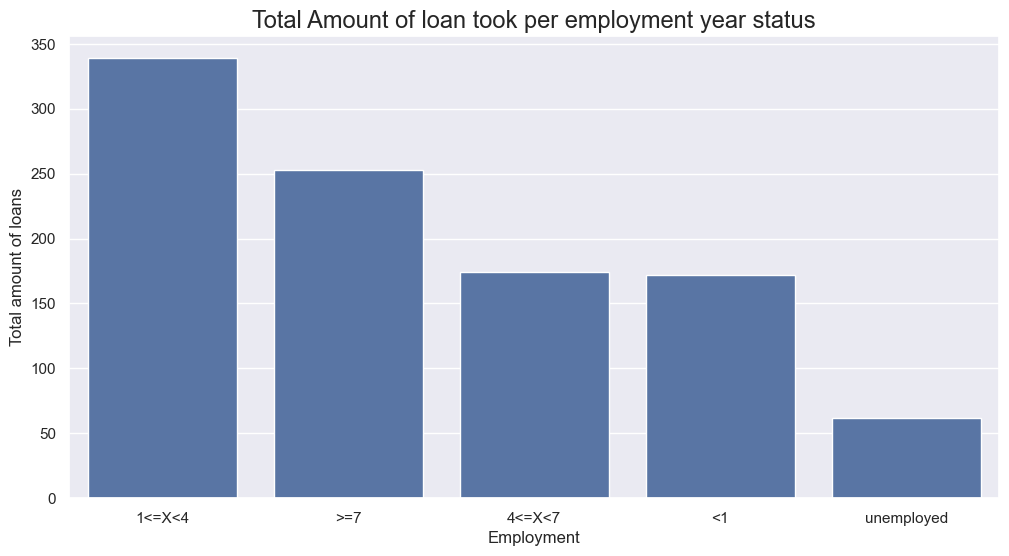

The 1<=X<4 employment group took 339 loans, they represent the 33.9 % of the dataset.
The >=7 employment group took 253 loans, they represent the 25.3 % of the dataset.
The 4<=X<7 employment group took 174 loans, they represent the 17.4 % of the dataset.
The <1 employment group took 172 loans, they represent the 17.2 % of the dataset.
The unemployed employment group took 62 loans, they represent the 6.2 % of the dataset.




In [7]:
# Groupping by employment and counting the empoyment
df5 = df.groupby('employment')['employment'].count().sort_values(ascending=False).to_frame()

# Getting the Weight (%) that each group represents on the dataset
df5['Weight'] = round((df5['employment']/ df5['employment'].sum())*100,2)
df5_str = df5.astype(str) # changing the values from int to str for printing

#Plotting a barplot regarding employment status
plt.figure(figsize=(12,6))
sns.barplot(x=df5.index,y=df5['employment'])
plt.title('Total Amount of loan took per employment year status',fontdict={'fontsize':'17'}, loc='center')
plt.xlabel('Employment')
plt.ylabel('Total amount of loans')
plt.show()

# Printing the 
for i in range(len(df5['employment'])):
    print(f'The {df5.index[i]} employment group took {df5.iloc[i,0]} loans, they represent the {df5.iloc[i,1]} % of the dataset.')

print('\n')

#### Task / Question 4.1: Check the relationship between the Credit amount and Employment Status. Check the mean loan requested per employment status¶

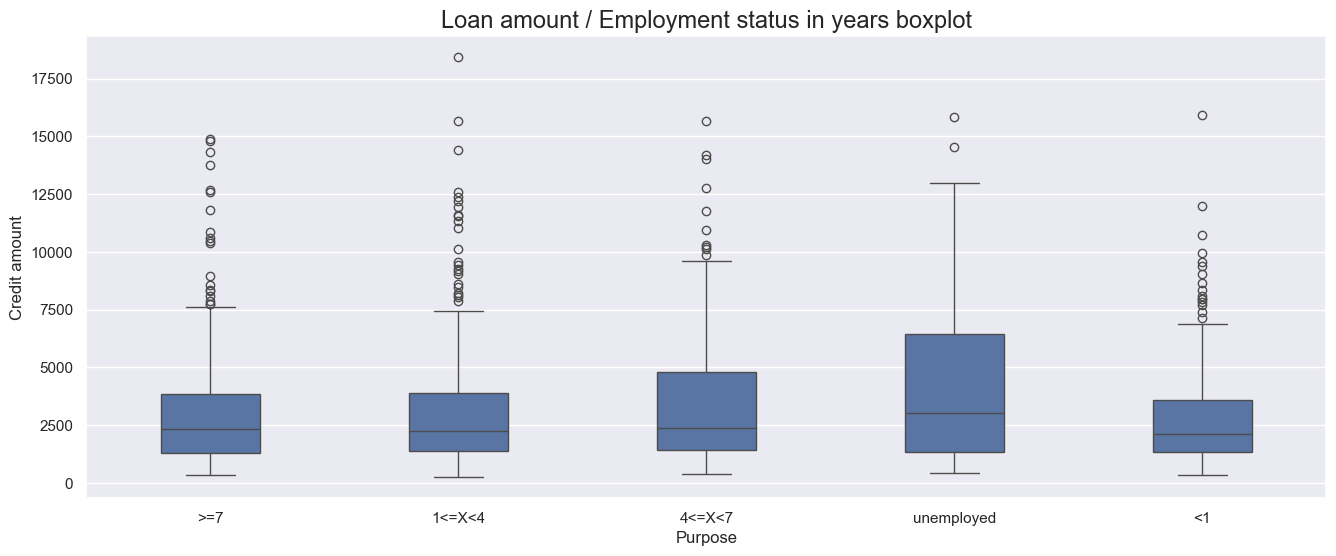



The mean credit amount take it for people with employment status 1<=X<4 was : 3125.29
The min credit amount take it for people with employment status 1<=X<4 was : 250.0
The max credit amount take it for people with employment status 1<=X<4 was : 18424.0


The mean credit amount take it for people with employment status 4<=X<7 was : 3601.7
The min credit amount take it for people with employment status 4<=X<7 was : 385.0
The max credit amount take it for people with employment status 4<=X<7 was : 15653.0


The mean credit amount take it for people with employment status <1 was : 2952.45
The min credit amount take it for people with employment status <1 was : 343.0
The max credit amount take it for people with employment status <1 was : 15945.0


The mean credit amount take it for people with employment status >=7 was : 3224.62
The min credit amount take it for people with employment status >=7 was : 338.0
The max credit amount take it for people with employment status >=7 was : 14896.

employment,1<=X<4,4<=X<7,<1,>=7,unemployed
count,339.0,174.0,172.0,253.0,62.0
mean,3125.29,3601.7,2952.45,3224.62,4216.76
std,2687.82,3025.7,2498.49,2809.15,3572.42
min,250.0,385.0,343.0,338.0,433.0
25%,1377.5,1450.5,1335.5,1300.0,1357.5
50%,2235.0,2386.0,2139.0,2337.0,3044.0
75%,3884.0,4783.75,3572.25,3832.0,6429.5
max,18424.0,15653.0,15945.0,14896.0,15857.0


In [8]:
# Groupping by employment and describing credit amount
df4 = df.groupby('employment')['credit_amount'].describe().round(2).T
df4 = df4.astype(str)
df4

# credit amount / employment Boxplot
plt.figure(figsize=(16,6))
sns.boxplot(data=df,y='credit_amount',width=0.4, orient='v', x='employment')
plt.title('Loan amount / Employment status in years boxplot',fontdict={'fontsize':'17'}, loc='center')
plt.xlabel('Purpose')
plt.ylabel('Credit amount')
plt.show()

# Printing the mean, min & max credit amount taken per employment status
print('\n')
for i in range(5):
    print('The mean credit amount take it for people with employment status '+ df4.columns[i] +' was : '+df4.iloc[1,i])
    print('The min credit amount take it for people with employment status '+ df4.columns[i] +' was : '+df4.iloc[3,i])
    print('The max credit amount take it for people with employment status '+ df4.columns[i] +' was : '+df4.iloc[-1,i])
    print('\n')

# Central measure variable of credit amount agaisnt employment status. Min, Max, Mean, Count, std, Q1, Q3
df4

-----

#### Question / Task 4.2: Check the purpose of each group of employment status and see what were they getting a loan for and see if there is a relation between them

Axes(0.125,0.11;0.775x0.77) 
The top porpuse for status employment of 1<=X<4 is "radio/tv" 



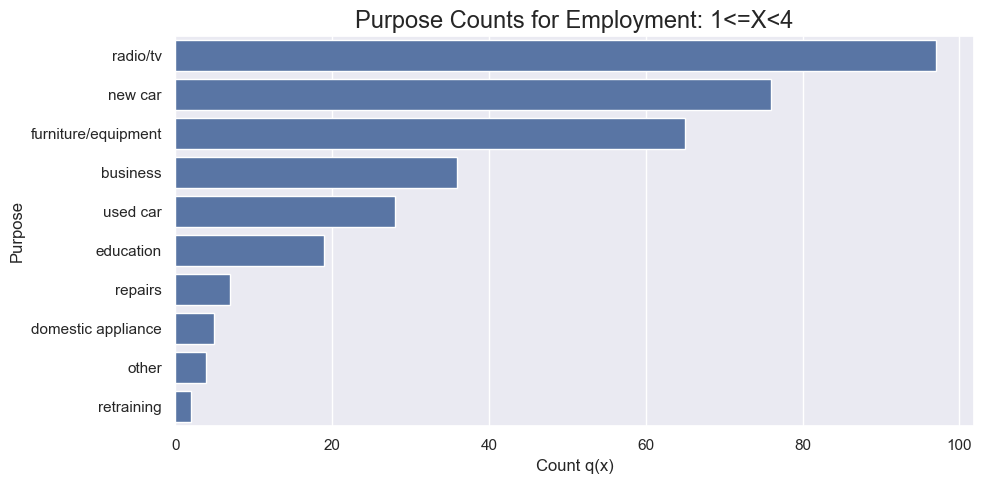

Axes(0.125,0.11;0.775x0.77) 
The top porpuse for status employment of 4<=X<7 is "radio/tv" 



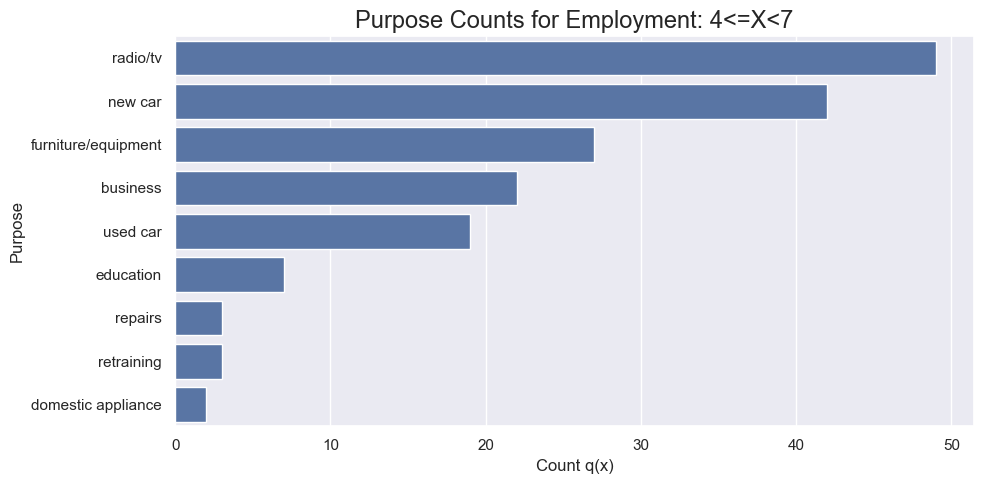

Axes(0.125,0.11;0.775x0.77) 
The top porpuse for status employment of <1 is "radio/tv" 



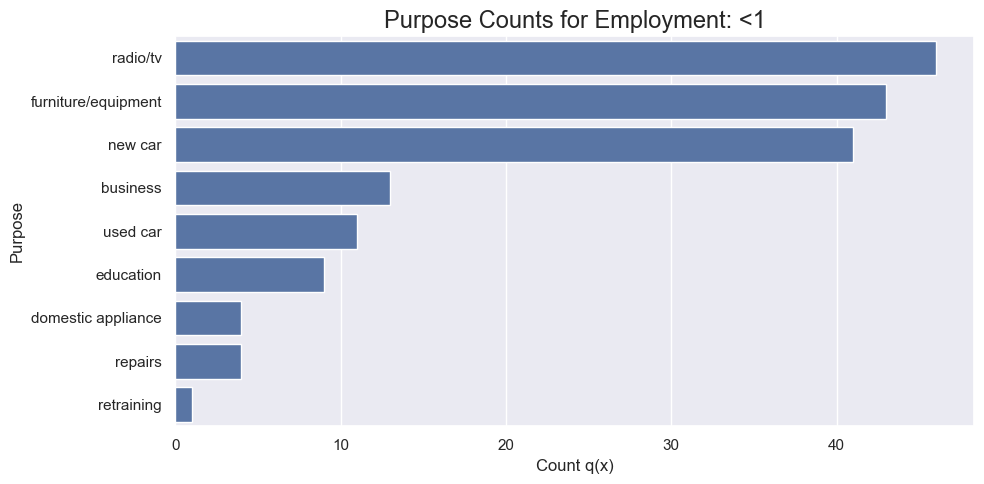

Axes(0.125,0.11;0.775x0.77) 
The top porpuse for status employment of >=7 is "radio/tv" 



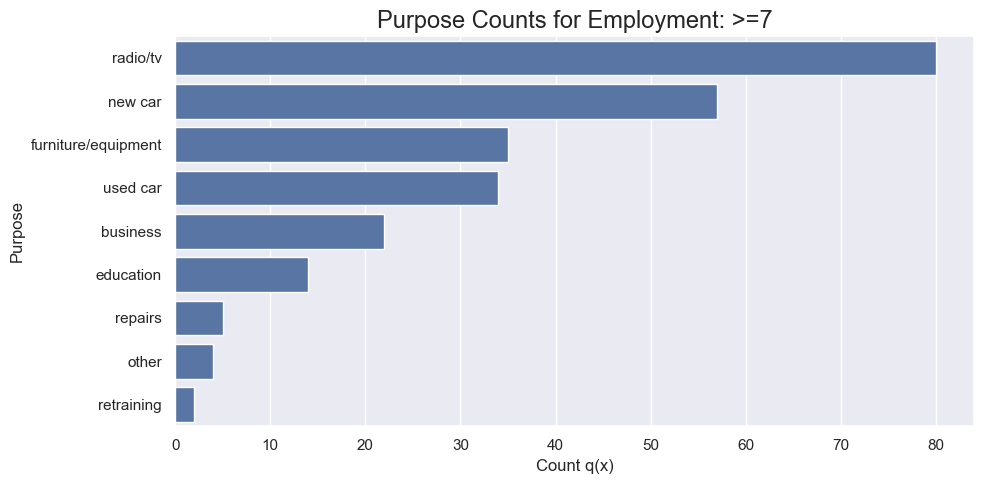

Axes(0.125,0.11;0.775x0.77) 
The top porpuse for status employment of unemployed is "new car" 



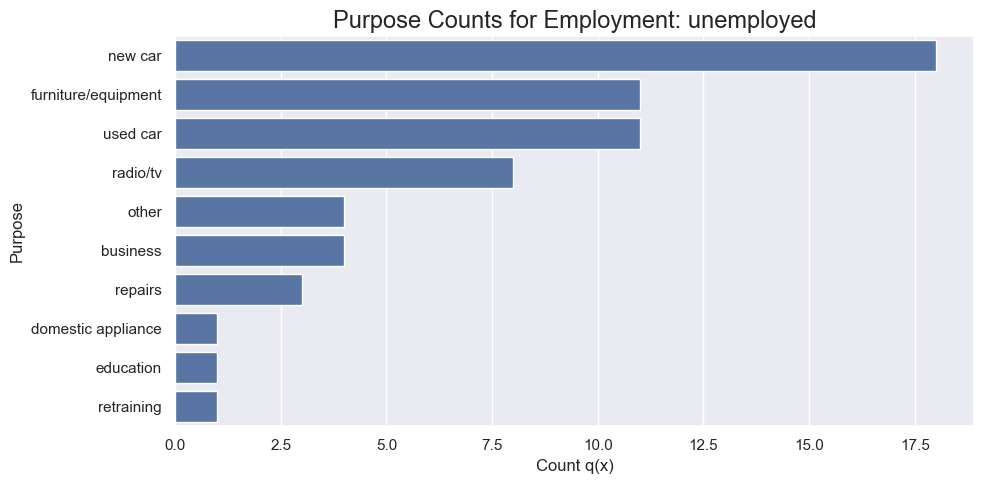

In [9]:
# Counting values and indexing them by employment and purpose and reseting the index
df4 = df[['employment','purpose']].value_counts().sort_index()
df4 = df4.reset_index()
df4.head()

# Getting the unique values from the column employment
employment_categories = df4['employment'].unique()

# Plotting a countplot regarding job status and purpose for each group and printing the top purpose for each group.
for category in employment_categories:
    plt.figure(figsize=(10, 5))  
    
    subset = df4[df4['employment'] == category]
    subset.sort_values(by='count', ascending=False, inplace=True)
    
    print(sns.barplot(data=subset, y='purpose', x='count',orient='h'),
          f'\nThe top porpuse for status employment of {category} is "{subset.iloc[0,1]}" \n')
    
    plt.title(f'Purpose Counts for Employment: {category}',fontdict={'fontsize':'17'}, loc='center')
    plt.ylabel('Purpose')
    plt.xlabel('Count q(x)')
    plt.tight_layout() 
    plt.show()

---

#### Task / Question 5: Check frequencies of loans regarding "Kind of job" variable and it's relationship between agaist loan duration

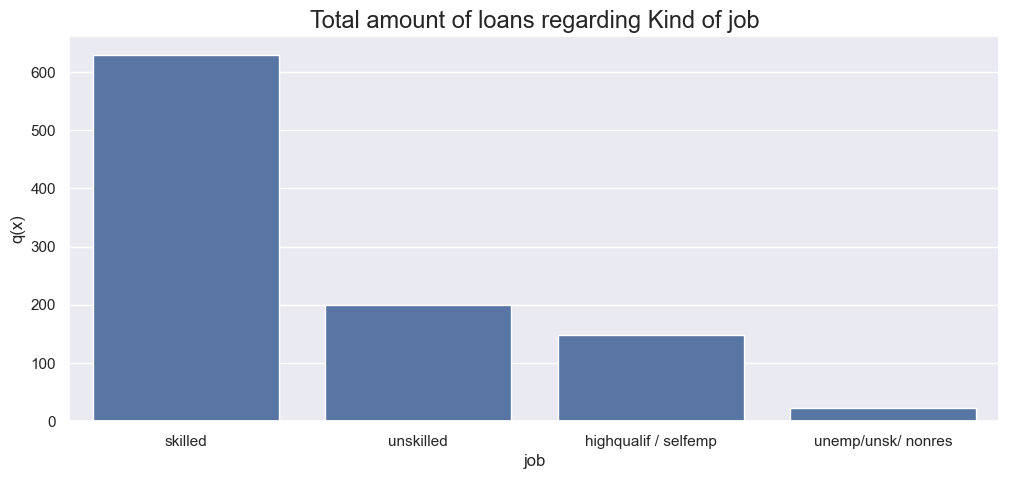



The workers with a kind of job skilled requested 630 loans and they represent the 63.0%
The workers with a kind of job unskilled requested 200 loans and they represent the 20.0%
The workers with a kind of job highqualif / selfemp requested 148 loans and they represent the 14.8%
The workers with a kind of job unemp/unsk/ nonres requested 22 loans and they represent the 2.2%


,duration,Weight
job,,
skilled,630,63.0
unskilled,200,20.0
highqualif / selfemp,148,14.8
unemp/unsk/ nonres,22,2.2


In [10]:
# Groupping by job and getting the frequencies for each kind of job the loan seekers have 
df6 = df.groupby('job')['duration'].count().sort_values(ascending=False).to_frame()
df6['Weight'] = round((df6['duration']/ df6['duration'].sum()*100),2)

# Plotting a barplot regarding frequencies of "Kind of job"
plt.figure(figsize=(12,5))
sns.barplot(x=df6.index,y=df6['duration'])
plt.title('Total amount of loans regarding Kind of job', fontdict={'fontsize':'17'}, loc='center')
plt.ylabel('q(x)')
plt.show()

print('\n')

# Printing the total requested loan for each group and their weight in the dataset
for i in range(len(df6['duration'])):
    print(f'The workers with a kind of job {df6.index[i]} requested {df6.iloc[i,0]} loans and they represent the {df6.iloc[i,1]}%')
df6


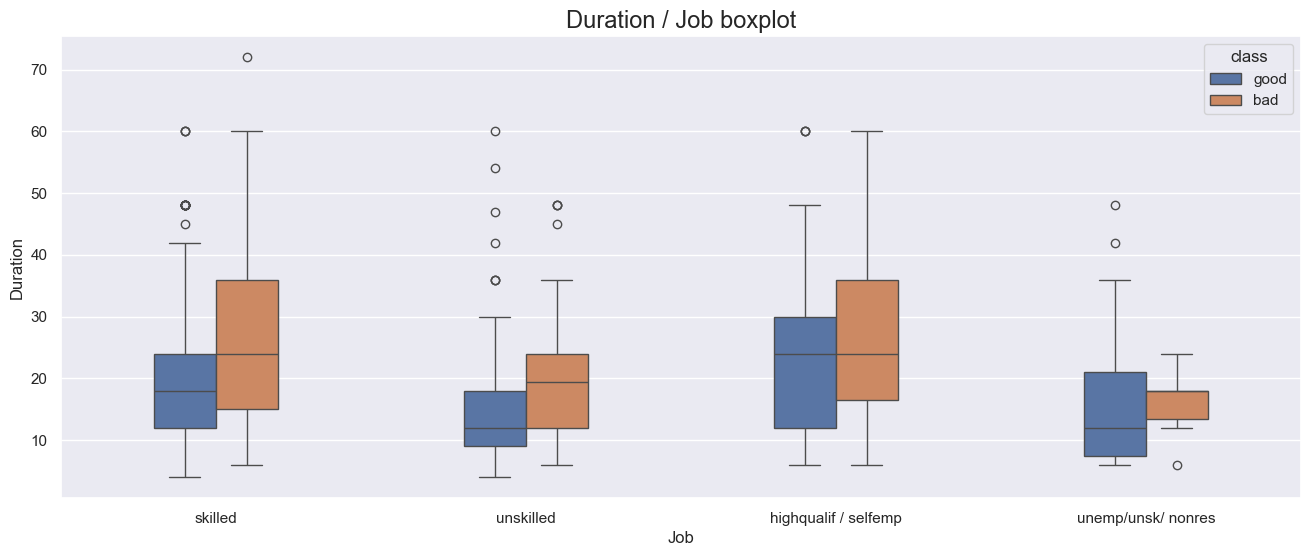



The count loan duration for highqualif / selfemp was 148.0
The count loan duration for skilled was 630.0
The count loan duration for unemp/unsk/ nonres was 22.0
The count loan duration for unskilled was 200.0

The mean loan duration for highqualif / selfemp was 25.17
The mean loan duration for skilled was 21.41
The mean loan duration for unemp/unsk/ nonres was 17.36
The mean loan duration for unskilled was 16.54

The std loan duration for highqualif / selfemp was 13.41
The std loan duration for skilled was 11.92
The std loan duration for unemp/unsk/ nonres was 11.59
The std loan duration for unskilled was 9.94

The min loan duration for highqualif / selfemp was 6.0
The min loan duration for skilled was 4.0
The min loan duration for unemp/unsk/ nonres was 6.0
The min loan duration for unskilled was 4.0

The 25% loan duration for highqualif / selfemp was 14.75
The 25% loan duration for skilled was 12.0
The 25% loan duration for unemp/unsk/ nonres was 9.75
The 25% loan duration for unsk

In [11]:
# Creating a dataframe that contains duration and job
df_skilled = df[['duration','job','class']]

# Plotting a box plot regarding job and loan duration
plt.figure(figsize=(16,6))
sns.boxplot(data=df_skilled,x='job',y='duration', width=0.4,hue='class')
plt.xlabel('Job')
plt.ylabel('Duration')
plt.title('Duration / Job boxplot',fontdict={'fontsize':'17'}, loc='center')
plt.show()

print('\n')
# Getting measures of central tendencies about duration agaisnt job and printing mean, min, max, Q1 & Q3
df_skilled = df_skilled.groupby('job')['duration'].describe().round(2)
df_skilled

for i in range(df_skilled.shape[1]):
    print(f'The {df_skilled.columns[i]} loan duration for {df_skilled.index[0]} was {df_skilled.iloc[0,i]}')
    print(f'The {df_skilled.columns[i]} loan duration for {df_skilled.index[1]} was {df_skilled.iloc[1,i]}')
    print(f'The {df_skilled.columns[i]} loan duration for {df_skilled.index[2]} was {df_skilled.iloc[2,i]}')
    print(f'The {df_skilled.columns[i]} loan duration for {df_skilled.index[3]} was {df_skilled.iloc[3,i]}\n')

Axes(0.125,0.11;0.775x0.77)


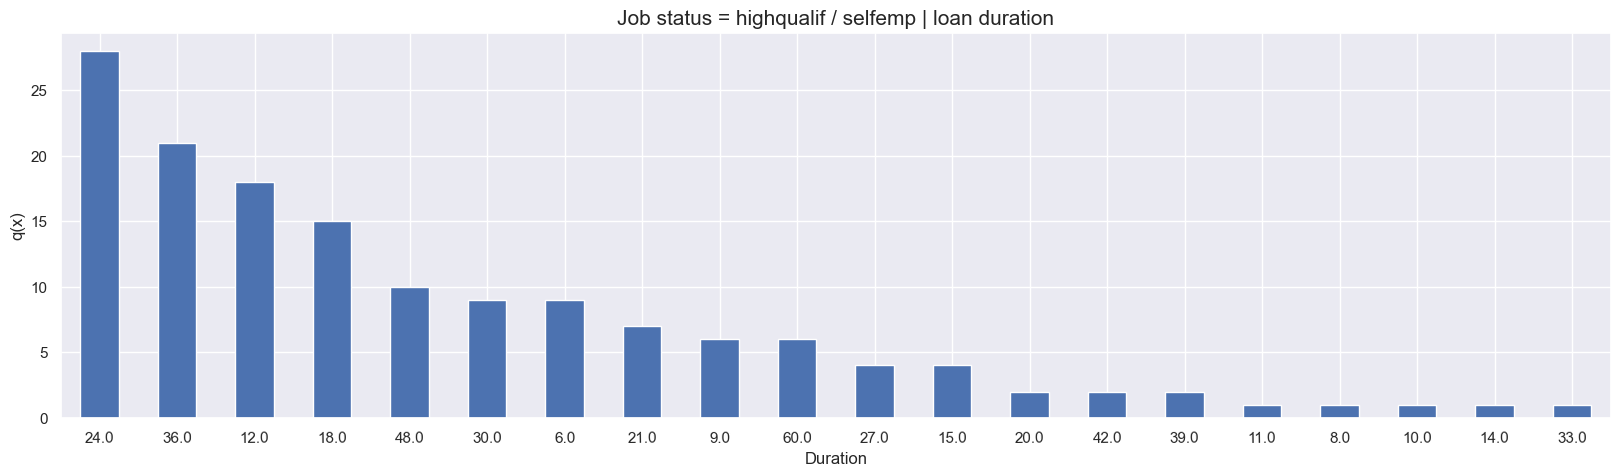

Axes(0.125,0.11;0.775x0.77)


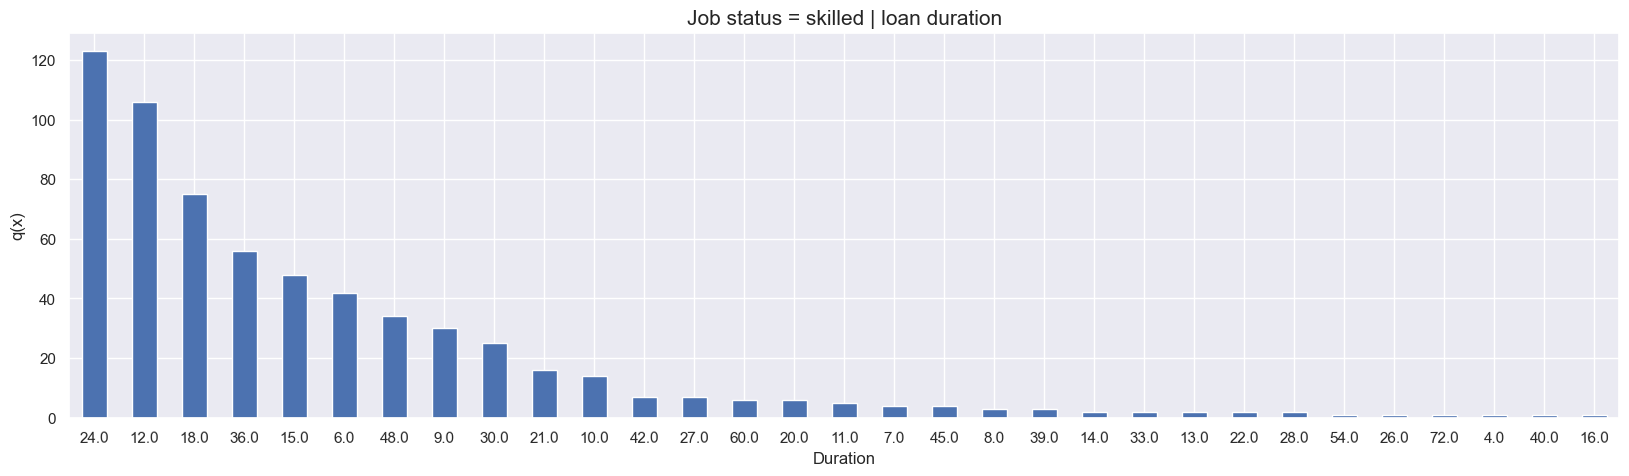

Axes(0.125,0.11;0.775x0.77)


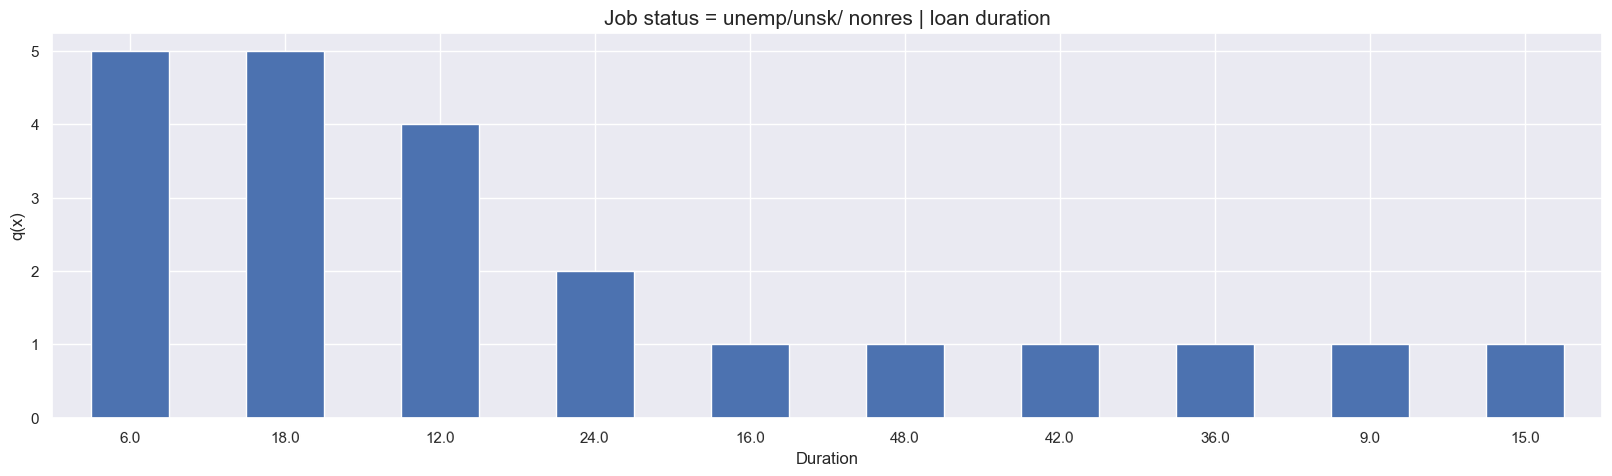

Axes(0.125,0.11;0.775x0.77)


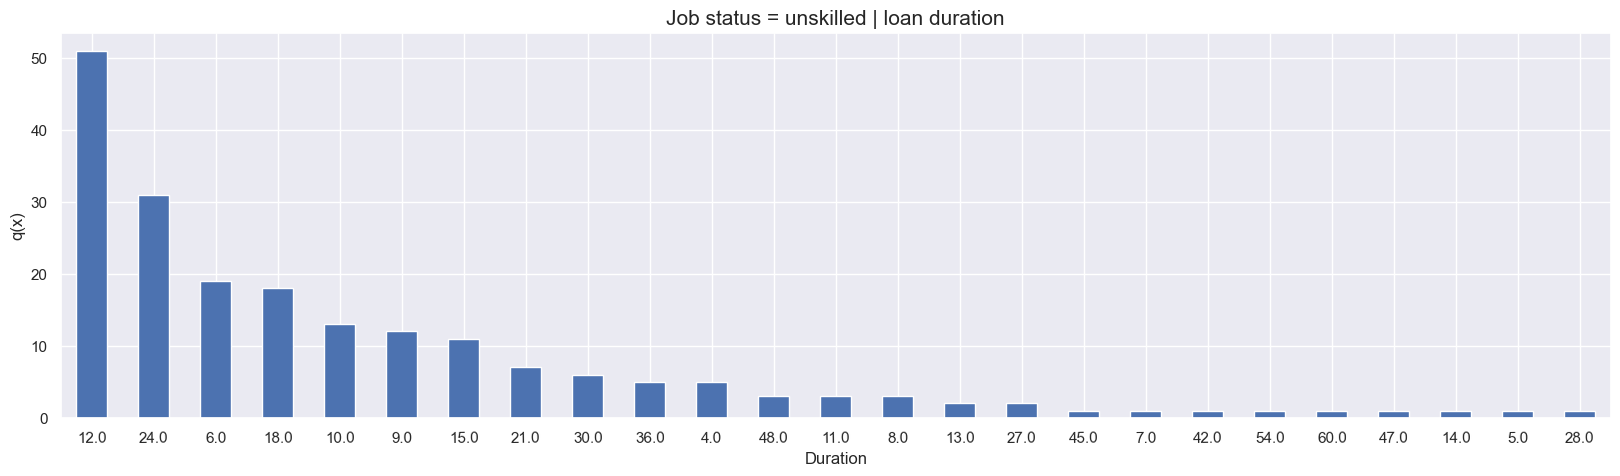

In [12]:
df_skilled = df
for i in np.unique(df['job']):
    df_skilled = df_skilled[['duration','job']]
    sub = df_skilled[df_skilled['job'] == i].value_counts()
    sub = sub.reset_index()
    print(sub.plot(kind='bar',x='duration',figsize=(20,5),rot=1,legend=None))
    
    plt.title(f'Job status = {i} | loan duration',fontdict={'fontsize':'15'})
    plt.xlabel('Duration')
    plt.ylabel('q(x)')
    plt.show()

----

#### Task / Question 6: Check the ages of the loan seekers and their class frequencies

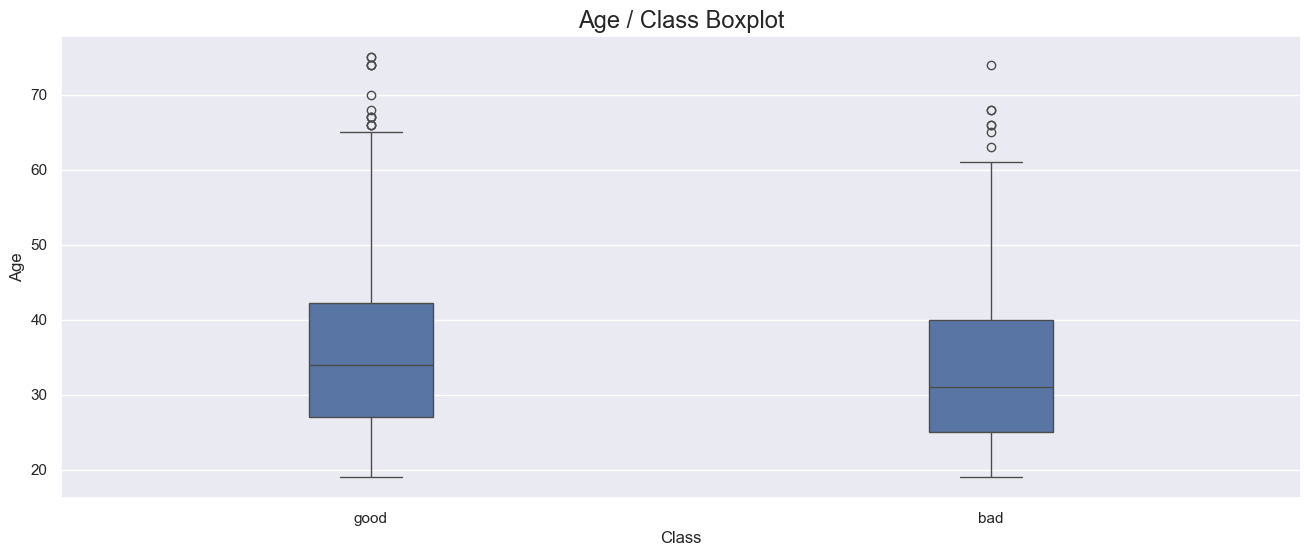

The bad class count age is 300.0
The good class count age is 700.0


The bad class mean age is 33.96
The good class mean age is 36.22


The bad class std age is 11.22
The good class std age is 11.38


The bad class min age is 19.0
The good class min age is 19.0


The bad class 25% age is 25.0
The good class 25% age is 27.0


The bad class 50% age is 31.0
The good class 50% age is 34.0


The bad class 75% age is 40.0
The good class 75% age is 42.25


The bad class max age is 74.0
The good class max age is 75.0




class,bad,good
count,300.00,700.00
mean,33.96,36.22
std,11.22,11.38
min,19.00,19.00
25%,25.00,27.00
50%,31.00,34.00
75%,40.00,42.25
max,74.00,75.00


In [13]:
# Age / class Boxplot
plt.figure(figsize=(16,6))
sns.boxplot(data=df[['class','age']], x='class',y='age', width =0.2)
plt.xlabel('Class')
plt.ylabel('Age')
plt.title('Age / Class Boxplot',fontdict={'fontsize':'17'}, loc='center')
plt.show()

# Groupping by class, describing age and printing info 
df_class = df.groupby('class')['age'].describe().T.round(2)

for i in range(len(df_class['good'])):
    print(f'The {df_class.columns[0]} class {df_class.index[i]} age is {df_class.iloc[i,0]}')
    print(f'The {df_class.columns[1]} class {df_class.index[i]} age is {df_class.iloc[i,1]}')
    print('\n')
df_class


#### Question / Task 7: Check which group of worker took most loans and their variables¶


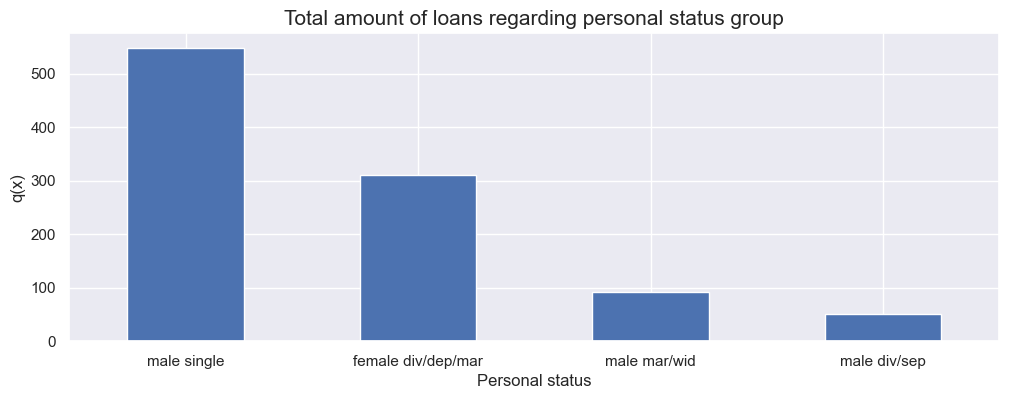


The male single group took 548 loans and they represent the 54.8% of the total amount of loans.

The female div/dep/mar group took 310 loans and they represent the 31.0% of the total amount of loans.

The male mar/wid group took 92 loans and they represent the 9.2% of the total amount of loans.

The male div/sep group took 50 loans and they represent the 5.0% of the total amount of loans.




,count,Weight
personal_status,,
male single,548,54.8
female div/dep/mar,310,31.0
male mar/wid,92,9.2
male div/sep,50,5.0


In [14]:
# groupping by personal status and counting them
df_personal_status = df['personal_status'].value_counts().sort_values(ascending=False).to_frame()
df_personal_status['Weight'] = round((df_personal_status['count']/df_personal_status['count'].sum())*100,2)
df_personal_status

df_personal_status.plot(kind='bar',y='count' , rot=0,figsize=(12,4), legend=None)
plt.title('Total amount of loans regarding personal status group', fontdict={'fontsize':'15'})
plt.xlabel('Personal status')
plt.ylabel('q(x)')
plt.show()


for i in range(len(df_personal_status['count'])):
        print(f'\nThe {df_personal_status.index[i]} group took {df_personal_status.iloc[i,0]} loans and they represent the {df_personal_status.iloc[i,1]}% of the total amount of loans.')
print('\n')
df_personal_status


----

### insights obtained from Face 2

Measures of central tendencies regarding Loan duration
* The mean loan duration is 20
* The std loan duration is 12.06
* The min loan duration is 4.0
* The Q1 loan duration is 12.0
* The median loan duration is 18
* The Q3 loan duration is 24
* The max loan duration is 72

Loan Purposes
* The Purpose Weight from the Total amount of loans
* The purpose radio/tv represent the 28.0% from the total amount of loans
* The purpose new car represent the 23.4% from the total amount of loans
* The purpose furniture/equipment represent the 18.1% from the total amount of loans
* The purpose used car represent the 10.3% from the total amount of loans
* The purpose business represent the 9.7% from the total amount of loans
* The purpose education represent the 5.0% from the total amount of loans
* The purpose repairs represent the 2.2% from the total amount of loans
* The purpose domestic appliance represent the 1.2% from the total amount of loans
* The purpose other represent the 1.2% from the total amount of loans
* The purpose retraining represent the 0.9% from the total amount of loans

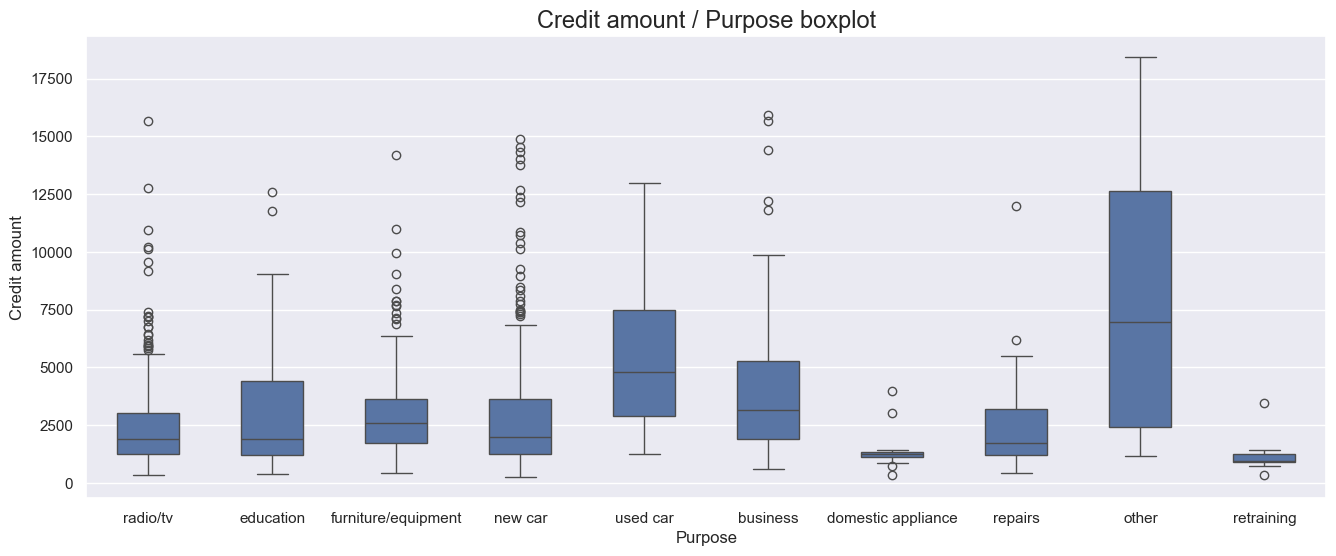



The mean credit amount taken for the purpose business is 4158.04 american dollars.
The mean credit amount taken for the purpose domestic appliance is 1498.0 american dollars.
The mean credit amount taken for the purpose education is 3180.4 american dollars.
The mean credit amount taken for the purpose furniture/equipment is 3066.99 american dollars.
The mean credit amount taken for the purpose new car is 3063.03 american dollars.
The mean credit amount taken for the purpose other is 8209.33 american dollars.
The mean credit amount taken for the purpose radio/tv is 2487.65 american dollars.
The mean credit amount taken for the purpose repairs is 2728.09 american dollars.
The mean credit amount taken for the purpose retraining is 1205.89 american dollars.

For more information, please go to the Task 3


In [15]:
plt.figure(figsize=(16,6))
sns.boxplot(data=df,y='credit_amount',width=0.5, orient='v', x='purpose')
plt.title('Credit amount / Purpose boxplot', fontdict={'fontsize':'17'})
plt.xlabel('Purpose')
plt.ylabel('Credit amount')
plt.show()

print('\n')
for i in range(0,len(df3.columns)):
    print(f'The mean credit amount taken for the purpose {df3.iloc[i,0]} is {df3.iloc[i,2]} american dollars.')

print('\nFor more information, please go to the Task 3')

### Face 3: Machine Learning

At this stage of the project, we will build a classification machine learning model to predict if a applicat is good or bad but firstly we will transform our categorical data into numerical

In [3]:
# Obtaining our string columns
categorical_columns = df.select_dtypes(include="string").columns
df[ df.select_dtypes(include="string").columns].head()

,checking_status,credit_history,purpose,savings_status,employment,personal_status,other_parties,property_magnitude,other_payment_plans,housing,job,own_telephone,foreign_worker,class
0,<0,critical/other existing credit,radio/tv,no known savings,>=7,male single,none,real estate,none,own,skilled,yes,yes,good
1,0<=X<200,existing paid,radio/tv,<100,1<=X<4,female div/dep/mar,none,real estate,none,own,skilled,none,yes,bad
2,no checking,critical/other existing credit,education,<100,4<=X<7,male single,none,real estate,none,own,unskilled resident,none,yes,good
3,<0,existing paid,furniture/equipment,<100,4<=X<7,male single,guarantor,life insurance,none,for free,skilled,none,yes,good
4,<0,delayed previously,new car,<100,1<=X<4,male single,none,no known property,none,for free,skilled,none,yes,bad


In [4]:
# Importing libraries
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

# Transforming categorical data into numerical
for i in categorical_columns:
    df[i] = le.fit_transform(df[i])

<Axes: >

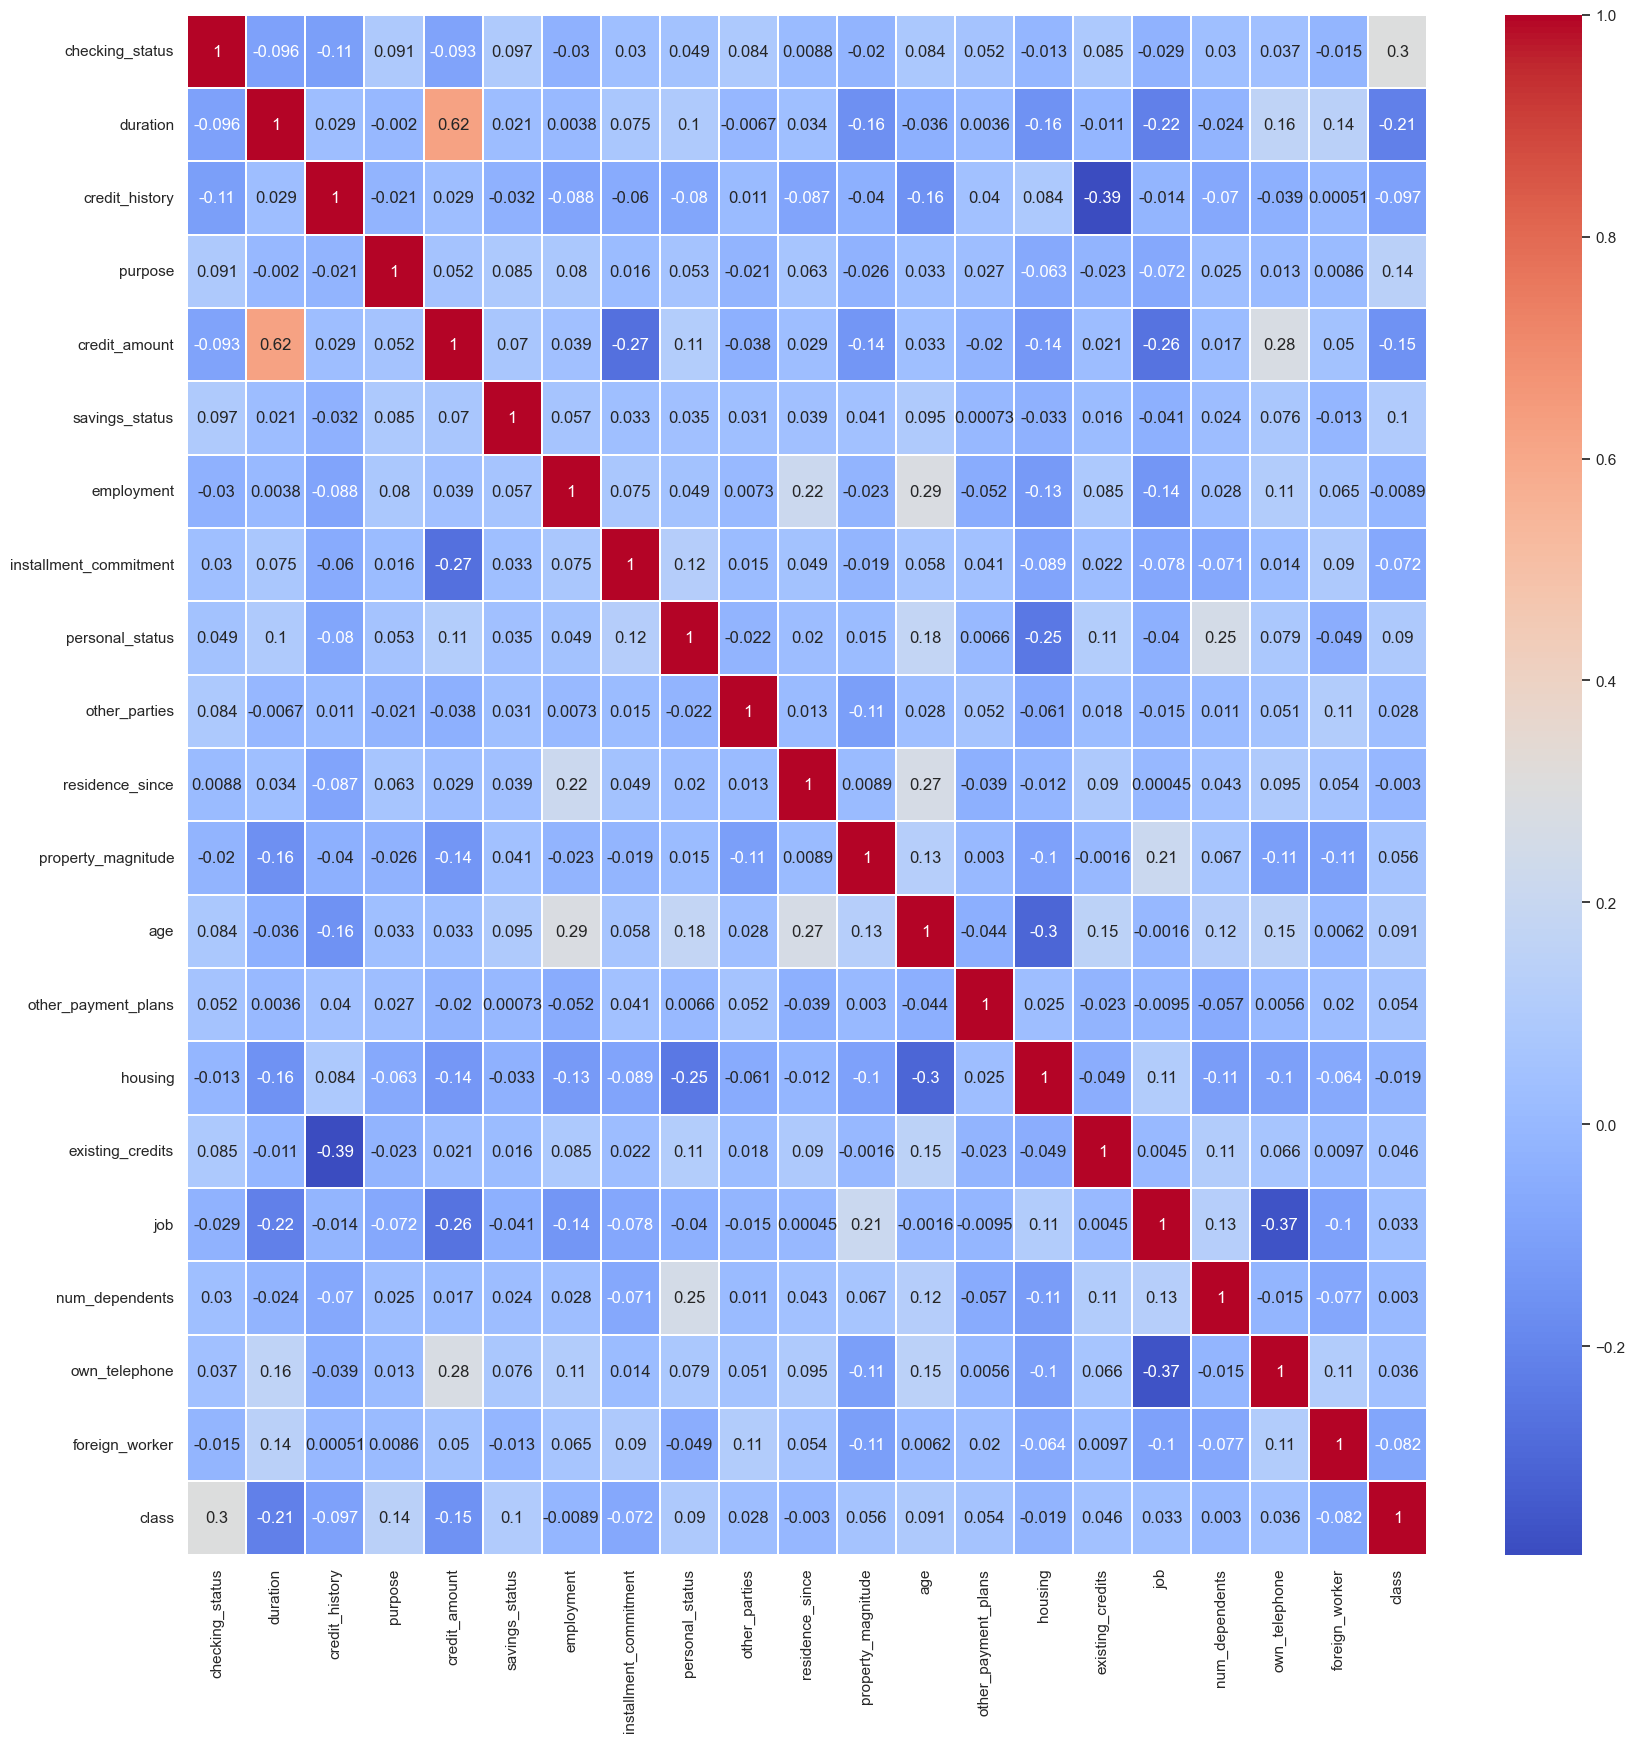

In [5]:
# Heatmap showing the correlation between the features
plt.figure(figsize=(20,20))
sns.heatmap(data=df.corr(), cmap="coolwarm", linewidths=0.1, annot=True) # Heat map


---

## Decision Tree Model - Credit Risk Project

In [81]:
# Importing libraries
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split

# Setting our target and independents columns
y= df["class"]
X = df.drop(columns= "class")


X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3, random_state = 42)
X_train.shape, y_train.shape, y_train.shape, y_test.shape

((700, 20), (700,), (700,), (300,))

In [82]:
dt_model = DecisionTreeClassifier(criterion = 'gini', random_state = 42)

df_model = dt_model.fit(X_train, y_train)

DTC_pred = dt_model.predict(X_test)

In [83]:
from sklearn import metrics

print("Accuracy = ", round(metrics.accuracy_score(y_test, DTC_pred),2))

Accuracy =  0.65


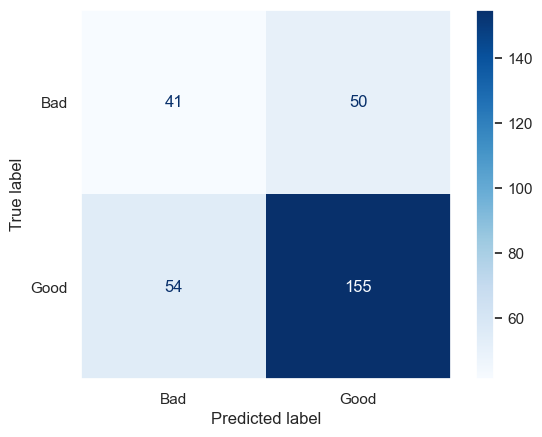


Classification Report - Credit Risk Project

               precision    recall  f1-score   support

         Bad       0.43      0.45      0.44        91
        Good       0.76      0.74      0.75       209

    accuracy                           0.65       300
   macro avg       0.59      0.60      0.59       300
weighted avg       0.66      0.65      0.66       300



In [84]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.metrics import confusion_matrix

X_pred = dt_model.predict(X_test)
cm = confusion_matrix(y_test, X_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels = ["Bad", "Good"]
)

disp.plot(cmap = "Blues", values_format = "d")
plt.grid(False)
plt.show()

print("\nClassification Report - Credit Risk Project")
print("\n",classification_report (y_test, X_pred, target_names = ["Bad", "Good"]))

-----

## Knn Value Model

#### Compare the training and testing accuracy of the models. Plot both accuracies to support conceptual understanding.

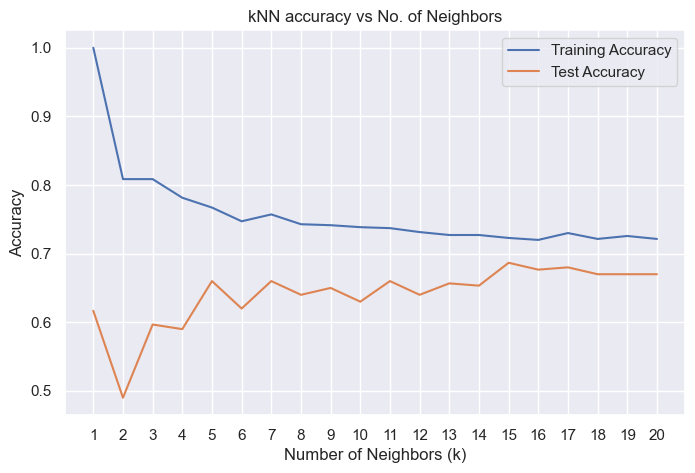

Best k = 15
Best Test Accuracy = 0.687


In [49]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = range(1, 21)

# Declaration and initialization of empty arrays
train_acc = []
test_acc = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors = k)
    knn.fit(X_train, y_train)

    y_train_pred = knn.predict(X_train)
    train_acc.append(accuracy_score(y_train, y_train_pred))  # Store the values for training accuracy

    y_test_pred = knn.predict(X_test)
    test_acc.append(accuracy_score(y_test, y_test_pred))    # Store the values for testing accuracy

best_k = k_values[test_acc.index(max(test_acc))]
best_test_accuracy = max(test_acc)

# Plotting the K nei
plt.figure(figsize = (8, 5))
plt.plot(k_values, train_acc, label = "Training Accuracy")
plt.plot(k_values, test_acc, label = "Test Accuracy")

plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.title("kNN accuracy vs No. of Neighbors")

plt.xticks(k_values)

plt.legend()
plt.show()

print(f"Best k = {best_k}")
print(f"Best Test Accuracy = {best_test_accuracy:.3f}")

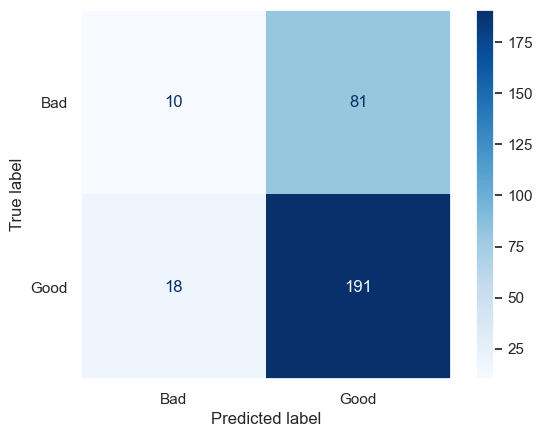

Classification Report:
              precision    recall  f1-score   support

         Bad       0.43      0.45      0.44        91
        Good       0.76      0.74      0.75       209

    accuracy                           0.65       300
   macro avg       0.59      0.60      0.59       300
weighted avg       0.66      0.65      0.66       300



In [95]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

X_pred = knn.predict(X_test)
cm = confusion_matrix(y_test, X_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels = ["Bad", "Good"]
)

disp.plot(cmap = "Blues", values_format = "d")
plt.grid(False)
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names = ["Bad", "Good"]))

----

## GaussianNB Model 

In [51]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
gnb = GaussianNB()
gnb.fit(X_train, y_train)

gnb_pred = gnb.predict(X_test)
gnb_preda = gnb.predict_proba(X_test)[:,1]

print("\n Gaussian naive Bayes - Without StandardScaler")
print(" Accuracy: ", round(accuracy_score(y_test, gnb_pred),4))
print(" ROC AUC: ", round(roc_auc_score(y_test, gnb_preda),4),"\n")
print(classification_report(y_test, gnb_pred))


 Gaussian naive Bayes - Without StandardScaler
 Accuracy:  0.7333
 ROC AUC:  0.7772 

              precision    recall  f1-score   support

           0       0.56      0.54      0.55        91
           1       0.80      0.82      0.81       209

    accuracy                           0.73       300
   macro avg       0.68      0.68      0.68       300
weighted avg       0.73      0.73      0.73       300



----

## AdaBoostClassifier Model

In [19]:
from sklearn.ensemble import AdaBoostClassifier
ada_model = AdaBoostClassifier(n_estimators = 200, learning_rate = 0.5,random_state =42)
ada_model.fit(X_train,y_train)

ada_pred = ada_model.predict(X_test)
ada_proba = ada_model.predict_proba(X_test)[:,1]

print("\nAdaBoost Model\n")
print(" Accuracy: ", round(accuracy_score(y_test, ada_pred),4))
print(" ROC AUC: ", round(roc_auc_score(y_test, ada_proba),4),"\n")
print(classification_report(y_test, ada_pred))


 AdaBoost Model
 Accuracy:  0.73
 ROC AUC:  0.7816 

              precision    recall  f1-score   support

           0       0.61      0.30      0.40        91
           1       0.75      0.92      0.83       209

    accuracy                           0.73       300
   macro avg       0.68      0.61      0.61       300
weighted avg       0.71      0.73      0.70       300



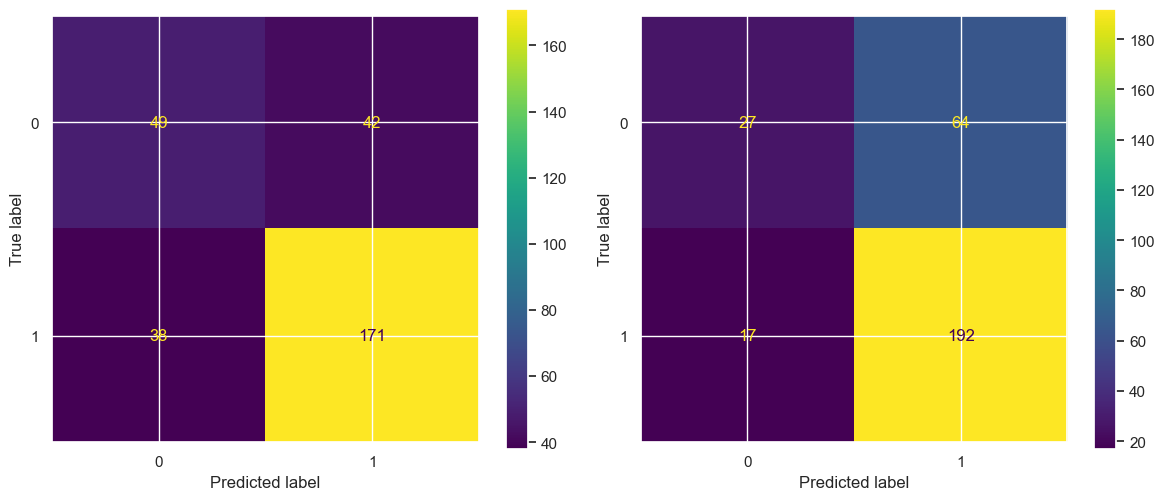

In [36]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

cm_gnb = confusion_matrix(y_test, gnb_pred)
cm_ada = confusion_matrix(y_test, ada_pred)

fig,axes = plt.subplots(1,2,figsize=(12,5))

ConfusionMatrixDisplay(confusion_matrix =cm_gnb).plot(ax=axes[0])
ConfusionMatrixDisplay(confusion_matrix =cm_ada).plot(ax=axes[1])
plt.tight_layout()
plt.show()

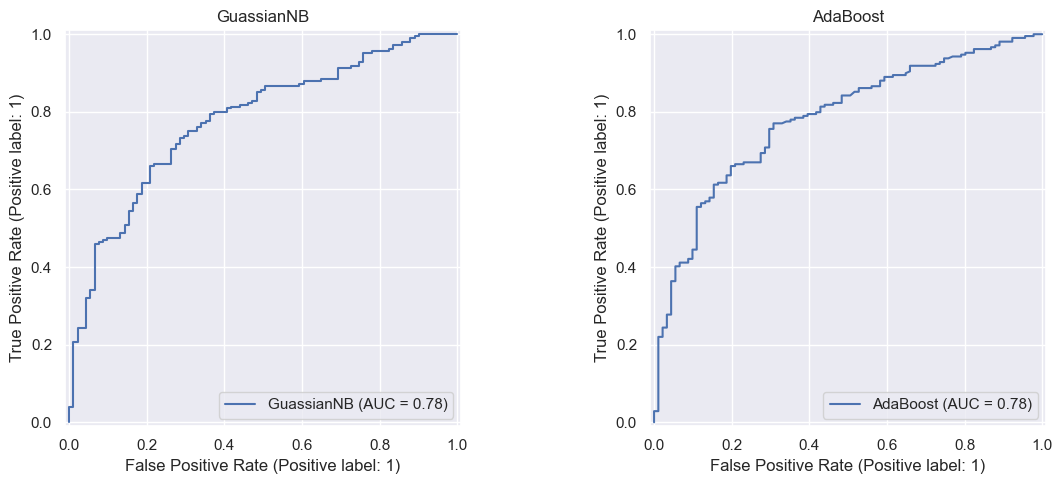

In [39]:
# Plotting of ROC curve

fig, axes= plt.subplots(1, 2, figsize= (12, 5))

RocCurveDisplay.from_predictions(y_test, gnb_preda, ax= axes[0], name= "GuassianNB")
axes[0].set_title("GuassianNB")

RocCurveDisplay.from_predictions(y_test, ada_proba, ax= axes[1], name= "AdaBoost")
axes[1].set_title("AdaBoost")

plt.tight_layout()
plt.show()

----

### Random Forest Model

Accuracy: 0.7567

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.69      0.36      0.47        91
           1       0.77      0.93      0.84       209

    accuracy                           0.76       300
   macro avg       0.73      0.65      0.66       300
weighted avg       0.74      0.76      0.73       300

Matriz de confusión:


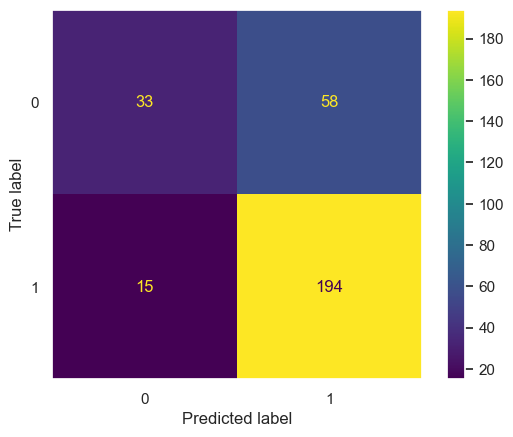

In [88]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Instanciar el modelo (puedes ajustar n_estimators según cuántos árboles quieras)
rand_forest_clas_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Entrenar el modelo con los datos de entrenamiento
rand_forest_clas_model.fit(X_train, y_train)

# 3. Realizar predicciones sobre el conjunto de prueba
RFC_pred = rand_forest_clas_model.predict(X_test)

# 4. Evaluar el rendimiento del modelo
print(f"Accuracy: {accuracy_score(y_test, RFC_pred):.4f}\n")
print("Reporte de clasificación:")
print(classification_report(y_test, RFC_pred))

print("Matriz de confusión:")
ConfusionMatrixDisplay(confusion_matrix(y_test, RFC_pred)).plot()
plt.grid(False)

----

## Result Summary from all our Classification models
Models executed:
* Decision Tree Model
* Knn Value Model
* GaussianNB Model
* AdaBoostClassifier Model
* Random Forest Model

In [98]:
# Decision Tree
y_pred = dt_model.predict(X_test)
print("Decision Tree Model Accuracy = ", round(metrics.accuracy_score(y_test, DTC_pred),2),"\n")
print("------------------------------------------------------------")

# Knn Value
print("Knn Value Model")
print(f"Best k = {best_k}")
print(f"Best Test Accuracy = {best_test_accuracy:.3f}")
print(classification_report(y_test, y_pred, target_names = ["Bad", "Good"]))
print("------------------------------------------------------------")

# Gaussian Naive Bayes / GaussianNB Model
print("\nGaussian Naive Bayes - Without StandardScaler")
print("Accuracy: ", round(accuracy_score(y_test, gnb_pred),4))
print("ROC AUC: ", round(roc_auc_score(y_test, gnb_preda),4))
print(classification_report(y_test, gnb_pred,target_names = ["Bad", "Good"]))
print("------------------------------------------------------------")

# AdaBoost Classifier model
print("\nAdaBoost Classifier Model")
print("Accuracy: ", round(accuracy_score(y_test, ada_pred),4))
print("ROC AUC: ", round(roc_auc_score(y_test, ada_proba),4))
print(classification_report(y_test, ada_pred,target_names = ["Bad", "Good"]))
print("------------------------------------------------------------")

# Random Forest Classifier Model
print("\nRandom Forest Classifier Model")
print(f"Accuracy: {accuracy_score(y_test, RFC_pred):.4f}")
print("Reporte de clasificación:")
print(classification_report(y_test, RFC_pred,target_names = ["Bad", "Good"]))

Decision Tree Model Accuracy =  0.65 

------------------------------------------------------------
Knn Value Model
Best k = 15
Best Test Accuracy = 0.687
              precision    recall  f1-score   support

         Bad       0.43      0.45      0.44        91
        Good       0.76      0.74      0.75       209

    accuracy                           0.65       300
   macro avg       0.59      0.60      0.59       300
weighted avg       0.66      0.65      0.66       300

------------------------------------------------------------

Gaussian Naive Bayes - Without StandardScaler
Accuracy:  0.7333
ROC AUC:  0.7772
              precision    recall  f1-score   support

         Bad       0.56      0.54      0.55        91
        Good       0.80      0.82      0.81       209

    accuracy                           0.73       300
   macro avg       0.68      0.68      0.68       300
weighted avg       0.73      0.73      0.73       300

------------------------------------------------